In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

from scaling.io import load_results

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

In [2]:
RESULT_FILES = {
    "CBN Unif-Gauss": "results/2026-04-02_17h41_cbn_unif_gauss/results.csv",
    "CBN Exp-Clayton": "results/2026-04-03_03h56_cbn_exp_clayton/results.csv",
    "CBN Unif-Mixture": "results/2026-04-03_12h05_cbn_unif_mixture/results.csv",
    "SEM Gaussian": "results/2026-04-02_10h34_sem_gaussian/results.csv",
    "SEM Laplace": "results/2026-04-01_16h49_sem_laplace/results.csv",
}

dfs = {name: load_results(path) for name, path in RESULT_FILES.items()}

In [3]:
def pareto_ranking(scores: pd.DataFrame) -> list[list[str]]:
    """
    Iteratively extract Pareto fronts to rank algorithms.

    Parameters
    ----------
    scores : DataFrame with columns ['algo', 'SHD', 'F1-Score'].
        SHD is to be minimised, F1-Score maximised.

    Returns
    -------
    list of lists: each inner list is a Pareto tier (best first),
    sub-sorted by F1 descending within the tier.
    """
    remaining = scores.set_index("algo")[["SHD", "F1-Score"]].copy()
    tiers = []

    while len(remaining) > 0:
        # An algo is Pareto-optimal if no other algo has both
        # lower-or-equal SHD AND higher-or-equal F1 (with >= 1 strict).
        dominated = set()
        for a in remaining.index:
            for b in remaining.index:
                if a == b:
                    continue
                if (remaining.loc[b, "SHD"] <= remaining.loc[a, "SHD"]
                        and remaining.loc[b, "F1-Score"] >= remaining.loc[a, "F1-Score"]
                        and (remaining.loc[b, "SHD"] < remaining.loc[a, "SHD"]
                             or remaining.loc[b, "F1-Score"] > remaining.loc[a, "F1-Score"])):
                    dominated.add(a)
                    break
        front = [a for a in remaining.index if a not in dominated]
        # Sub-sort by F1 descending
        front = sorted(front, key=lambda a: remaining.loc[a, "F1-Score"], reverse=True)
        tiers.append(front)
        remaining = remaining.drop(front)

    return tiers


def format_ranking(tiers: list[list[str]]) -> str:
    """Pretty-print a Pareto ranking."""
    parts = []
    for tier in tiers:
        parts.append(" >(f1) ".join(tier))
    return " >(pareto) ".join(parts)

## Rankings by dataset and configuration

In [4]:
all_rankings = []

for ds_name, df in dfs.items():
    subset = df[df["n_samples"] == 5000]
    for n_vars in sorted(subset["n_vars"].unique()):
        sub = subset[subset["n_vars"] == n_vars]
        scores = sub.groupby("algo")[["SHD", "F1-Score"]].mean().reset_index()
        tiers = pareto_ranking(scores)
        all_rankings.append({
            "dataset": ds_name,
            "n_vars": n_vars,
            "ranking": format_ranking(tiers),
            "tiers": tiers,
        })

ranking_df = pd.DataFrame(all_rankings)
pd.set_option("display.max_colwidth", None)
ranking_df[["dataset", "n_vars", "ranking"]]

,dataset,n_vars,ranking
0,CBN Unif-Gauss,10,NOTEARS Disc. >(f1) CPC >(pareto) LiNGAM >(f1) CMIIC >(f1) MIIC >(pareto) GHC+BDeu >(pareto) NOTEARS
1,CBN Unif-Gauss,20,NOTEARS Disc. >(pareto) MIIC >(pareto) CPC >(pareto) CMIIC >(pareto) GHC+BDeu >(pareto) LiNGAM >(f1) NOTEARS
2,CBN Exp-Clayton,10,CPC >(pareto) LiNGAM >(f1) NOTEARS Disc. >(f1) MIIC >(pareto) CMIIC >(pareto) GHC+BDeu >(pareto) NOTEARS
3,CBN Exp-Clayton,20,NOTEARS Disc. >(pareto) CPC >(f1) MIIC >(pareto) CMIIC >(pareto) LiNGAM >(f1) GHC+BDeu >(pareto) NOTEARS
4,CBN Unif-Mixture,10,MIIC >(pareto) CPC >(f1) GHC+BDeu >(pareto) LiNGAM >(f1) CMIIC >(pareto) NOTEARS Disc. >(pareto) NOTEARS
5,CBN Unif-Mixture,20,MIIC >(pareto) CPC >(pareto) GHC+BDeu >(pareto) LiNGAM >(f1) CMIIC >(pareto) NOTEARS Disc. >(pareto) NOTEARS
6,SEM Gaussian,10,NOTEARS >(pareto) CPC >(f1) NOTEARS Disc. >(pareto) MIIC >(pareto) LiNGAM >(f1) GHC+BDeu >(f1) CMIIC
7,SEM Gaussian,20,NOTEARS >(pareto) MIIC >(pareto) NOTEARS Disc. >(pareto) CPC >(pareto) CMIIC >(pareto) GHC+BDeu >(pareto) LiNGAM
8,SEM Laplace,10,LiNGAM >(pareto) NOTEARS >(pareto) CPC >(f1) NOTEARS Disc. >(pareto) MIIC >(pareto) CMIIC >(pareto) GHC+BDeu
9,SEM Laplace,20,LiNGAM >(pareto) NOTEARS >(pareto) MIIC >(pareto) NOTEARS Disc. >(pareto) CMIIC >(pareto) CPC >(pareto) GHC+BDeu


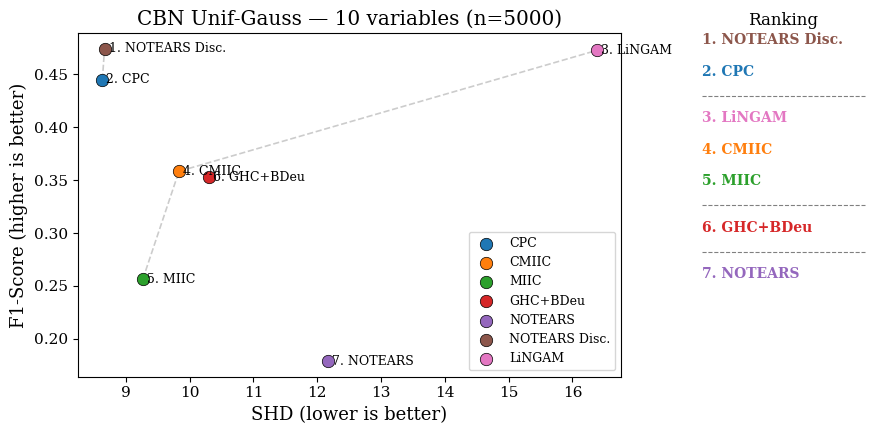

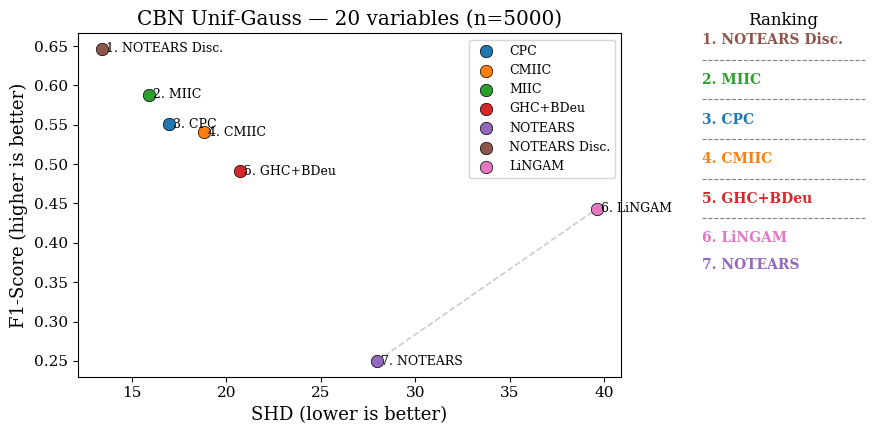

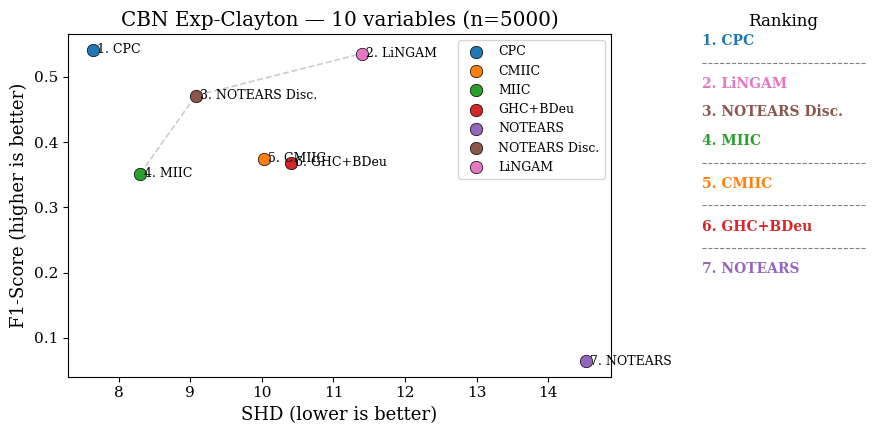

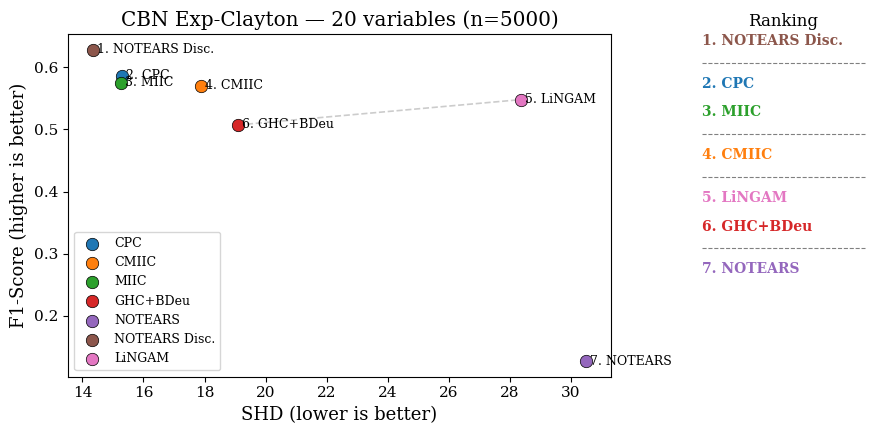

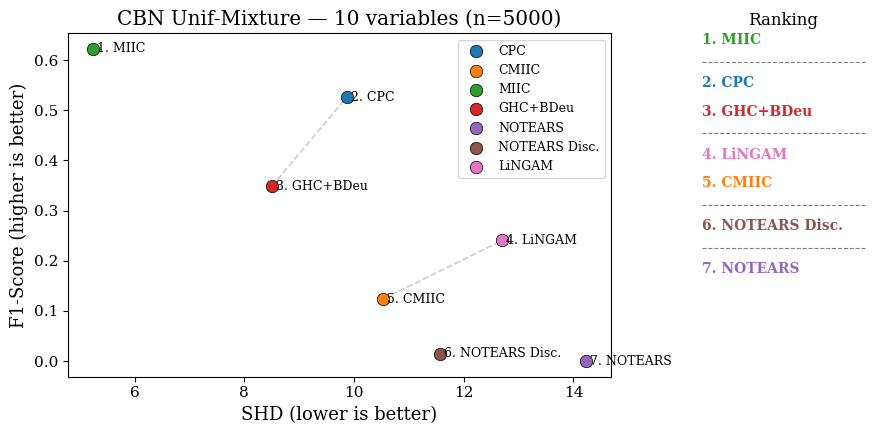

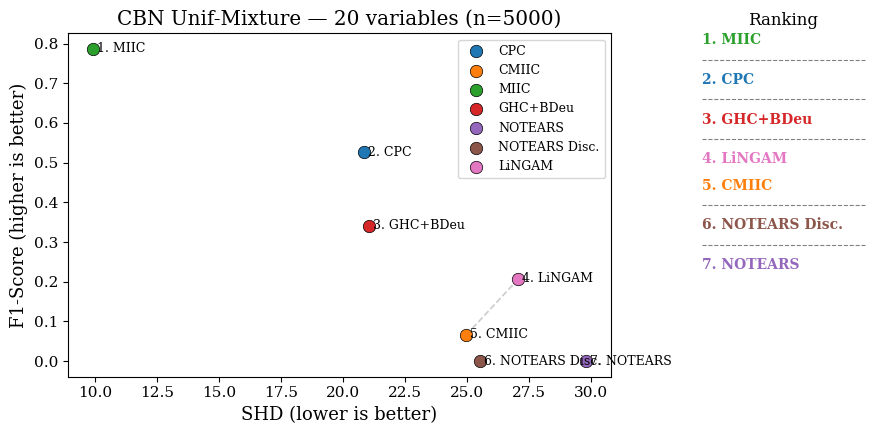

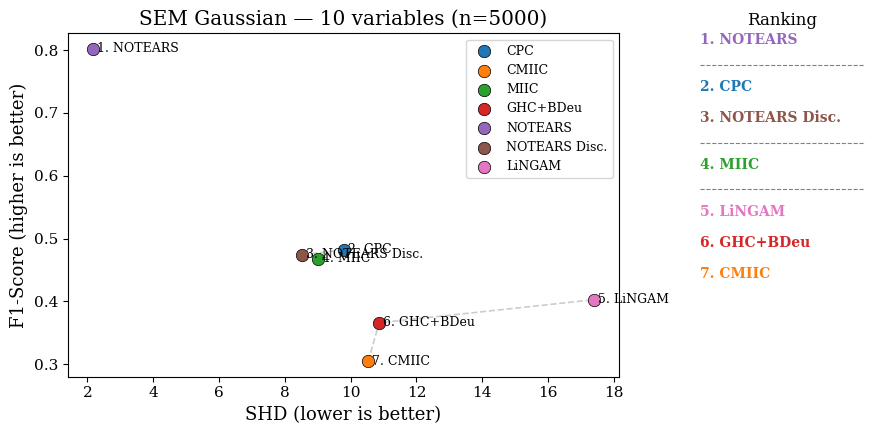

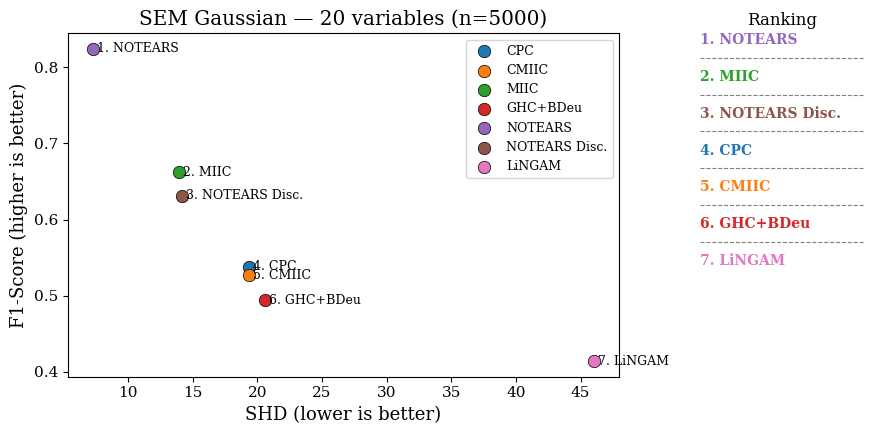

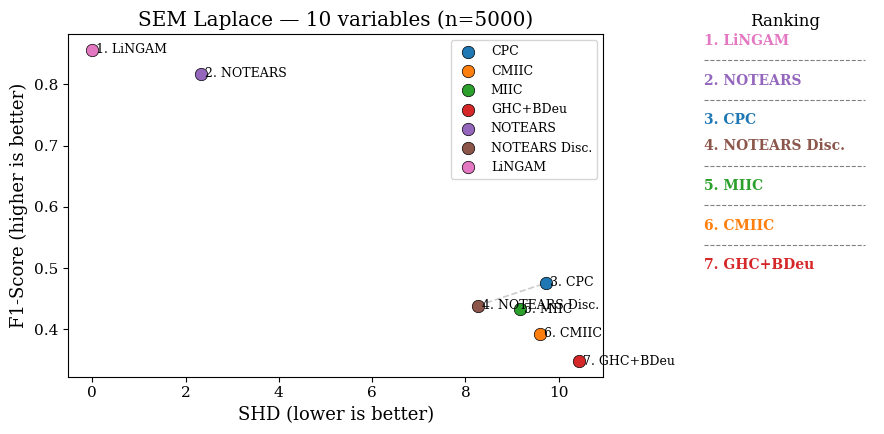

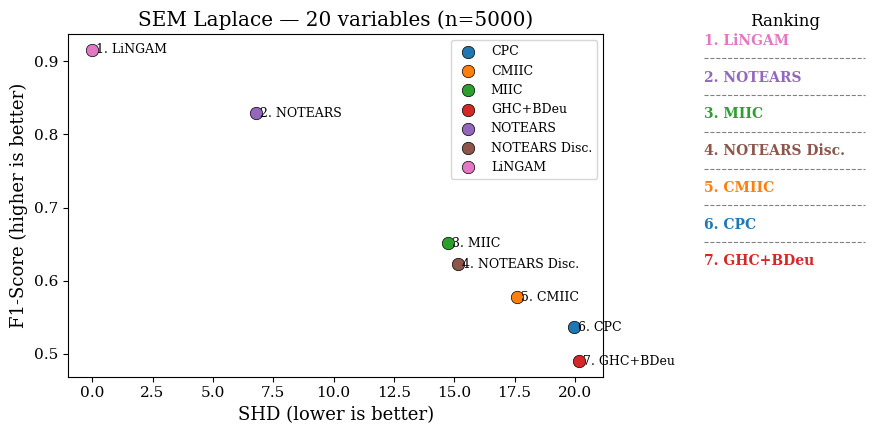

In [5]:
# Match seaborn default hue order (order of first appearance in the CSVs)
ALGO_ORDER = ["CPC", "CMIIC", "MIIC", "GHC+BDeu", "NOTEARS", "NOTEARS Disc.", "LiNGAM"]
palette = sns.color_palette()
ALGO_COLORS = {algo: palette[i] for i, algo in enumerate(ALGO_ORDER)}

for row in all_rankings:
    ds_name = row["dataset"]
    n_vars = row["n_vars"]
    tiers = row["tiers"]

    # Recover mean scores
    df = dfs[ds_name]
    subset = df[(df["n_samples"] == 5000) & (df["n_vars"] == n_vars)]
    scores = subset.groupby("algo")[["SHD", "F1-Score"]].mean()

    fig, (ax, ax_rank) = plt.subplots(
        1, 2, figsize=(9, 4.5),
        gridspec_kw={"width_ratios": [3, 1]},
    )

    # Assign global rank
    global_rank = {}
    r = 1
    for tier in tiers:
        for algo in tier:
            global_rank[algo] = r
            r += 1
    n_algos = len(global_rank)

    # Draw Pareto front lines (dashed gray)
    for tier in tiers:
        tier_scores = scores.loc[tier].sort_values("SHD")
        if len(tier_scores) > 1:
            ax.plot(
                tier_scores["SHD"], tier_scores["F1-Score"],
                "--", color="gray", alpha=0.4, linewidth=1.2, zorder=1,
            )

    # Scatter each algo with its own color
    for algo in ALGO_ORDER:
        if algo in scores.index:
            ax.scatter(
                scores.loc[algo, "SHD"], scores.loc[algo, "F1-Score"],
                color=ALGO_COLORS[algo], s=80, zorder=2,
                edgecolors="black", linewidths=0.5, label=algo,
            )

    # Annotate with rank and name on scatter
    for algo, rank in global_rank.items():
        x, y = scores.loc[algo, "SHD"], scores.loc[algo, "F1-Score"]
        ax.annotate(
            f" {rank}. {algo}", (x, y),
            fontsize=9, va="center", ha="left",
        )

    ax.set_xlabel("SHD (lower is better)")
    ax.set_ylabel("F1-Score (higher is better)")
    ax.set_title(f"{ds_name} — {n_vars} variables (n=5000)")
    ax.legend(fontsize=9, frameon=True)

    # Right panel: ranking as text
    ax_rank.axis("off")
    ax_rank.set_title("Ranking", fontsize=12)
    tier_start = 1
    y_pos = 1.0
    line_height = 1.0 / (n_algos + len(tiers))
    for tier_idx, tier in enumerate(tiers):
        if tier_idx > 0:
            # Pareto separator line
            ax_rank.axhline(y=y_pos, color="gray", linewidth=0.8, linestyle="--", xmin=0.05, xmax=0.95)
            y_pos -= line_height * 0.5
        for algo in tier:
            rank = global_rank[algo]
            ax_rank.text(
                0.05, y_pos, f"{rank}. {algo}",
                transform=ax_rank.transAxes,
                fontsize=10, va="top", ha="left",
                color=ALGO_COLORS[algo], fontweight="bold",
            )
            y_pos -= line_height

    fig.tight_layout()
    plt.show()

## Aggregate ranking scores

Assign a rank (1 = best) to each algorithm in each configuration, then average across all configurations.

In [6]:
# Build a table: for each config, assign rank 1..N to each algo
rank_records = []
for row in all_rankings:
    rank = 1
    for tier in row["tiers"]:
        for algo in tier:
            rank_records.append({
                "dataset": row["dataset"],
                "n_vars": row["n_vars"],
                "algo": algo,
                "rank": rank,
            })
            rank += 1

rank_df = pd.DataFrame(rank_records)

# Average rank per algo
avg_rank = rank_df.groupby("algo")["rank"].mean().sort_values()
print("Average rank across all configurations (n_samples=5000):")
print(avg_rank.to_string())

Average rank across all configurations (n_samples=5000):
algo
CPC              2.7
MIIC             3.0
NOTEARS Disc.    3.2
LiNGAM           3.8
NOTEARS          4.8
CMIIC            5.0
GHC+BDeu         5.5


In [7]:
def pareto_ranking_by_shd(scores: pd.DataFrame) -> list[list[str]]:
    """Same Pareto fronts as pareto_ranking, but sub-sorted by SHD ascending."""
    remaining = scores.set_index("algo")[["SHD", "F1-Score"]].copy()
    tiers = []
    while len(remaining) > 0:
        dominated = set()
        for a in remaining.index:
            for b in remaining.index:
                if a == b:
                    continue
                if (remaining.loc[b, "SHD"] <= remaining.loc[a, "SHD"]
                        and remaining.loc[b, "F1-Score"] >= remaining.loc[a, "F1-Score"]
                        and (remaining.loc[b, "SHD"] < remaining.loc[a, "SHD"]
                             or remaining.loc[b, "F1-Score"] > remaining.loc[a, "F1-Score"])):
                    dominated.add(a)
                    break
        front = [a for a in remaining.index if a not in dominated]
        front = sorted(front, key=lambda a: remaining.loc[a, "SHD"])  # SHD ascending
        tiers.append(front)
        remaining = remaining.drop(front)
    return tiers


def compute_ranks(ranking_func, dfs):
    """Apply a ranking function to all configs and return a DataFrame of ranks."""
    records = []
    for ds_name, df in dfs.items():
        subset = df[df["n_samples"] == 5000]
        for n_vars in sorted(subset["n_vars"].unique()):
            sub = subset[subset["n_vars"] == n_vars]
            scores = sub.groupby("algo")[["SHD", "F1-Score"]].mean().reset_index()
            tiers = ranking_func(scores)
            rank = 1
            for tier in tiers:
                for algo in tier:
                    records.append({
                        "dataset": ds_name, "n_vars": n_vars,
                        "algo": algo, "rank": rank,
                    })
                    rank += 1
    return pd.DataFrame(records)


def rank_by_f1(scores):
    """Rank purely by F1-Score descending — each algo in its own tier."""
    ordered = scores.sort_values("F1-Score", ascending=False)
    return [[a] for a in ordered["algo"]]


def rank_by_shd(scores):
    """Rank purely by SHD ascending — each algo in its own tier."""
    ordered = scores.sort_values("SHD", ascending=True)
    return [[a] for a in ordered["algo"]]


rank_f1_df = compute_ranks(rank_by_f1, dfs)
rank_shd_df = compute_ranks(rank_by_shd, dfs)
rank_pareto_f1_df = compute_ranks(pareto_ranking, dfs)  # existing function
rank_pareto_shd_df = compute_ranks(pareto_ranking_by_shd, dfs)

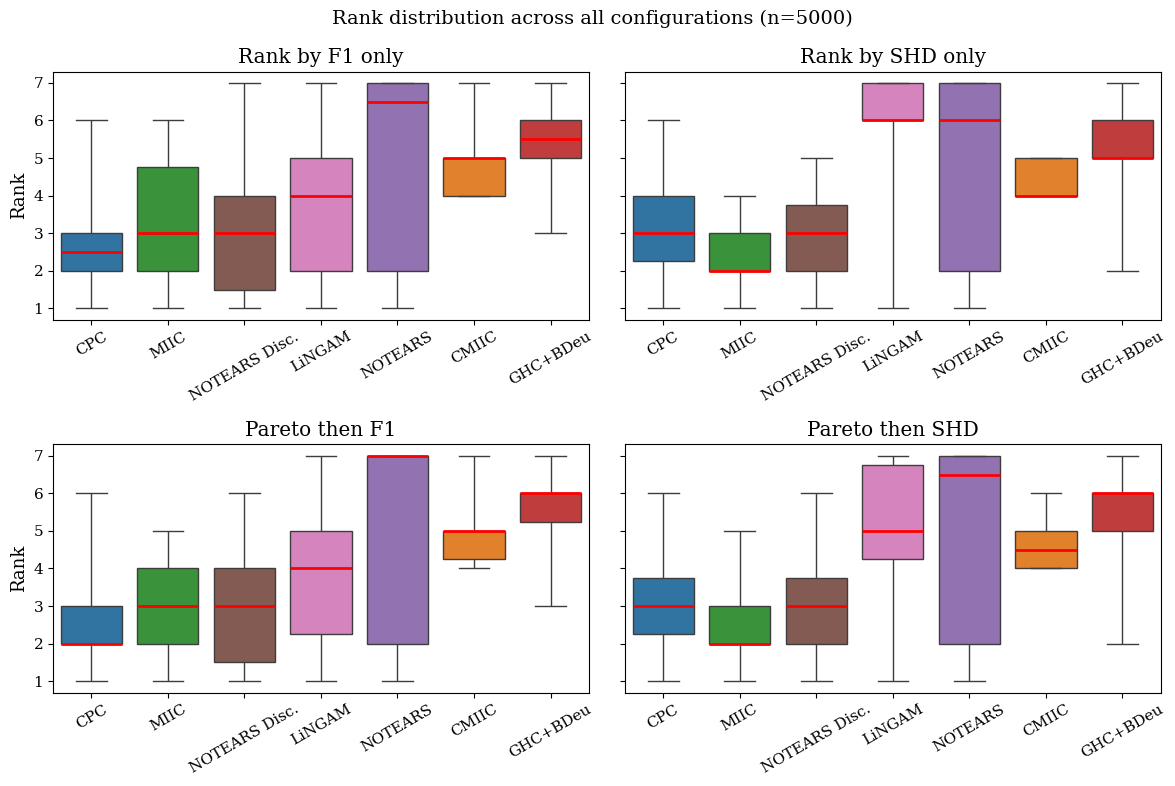

In [8]:
ranking_methods = {
    "Rank by F1 only": rank_f1_df,
    "Rank by SHD only": rank_shd_df,
    "Pareto then F1": rank_pareto_f1_df,
    "Pareto then SHD": rank_pareto_shd_df,
}

# Sort algos by overall average rank (Pareto+F1) for consistent x-axis order
algo_order_by_avg = (
    rank_pareto_f1_df.groupby("algo")["rank"].mean()
    .sort_values().index.tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (title, rdf) in zip(axes.flat, ranking_methods.items()):
    sns.boxplot(
        data=rdf, x="algo", y="rank", hue="algo", order=algo_order_by_avg,
        hue_order=algo_order_by_avg, palette=ALGO_COLORS, ax=ax,
        whis=[0, 100], fliersize=0, legend=False,
        medianprops={"color": "red", "linewidth": 2},
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Rank")
    ax.tick_params(axis="x", rotation=30)
    ax.set_yticks(range(1, 8))
    ax.invert_yaxis()

fig.suptitle("Rank distribution across all configurations (n=5000)", fontsize=14)
fig.tight_layout()
plt.show()

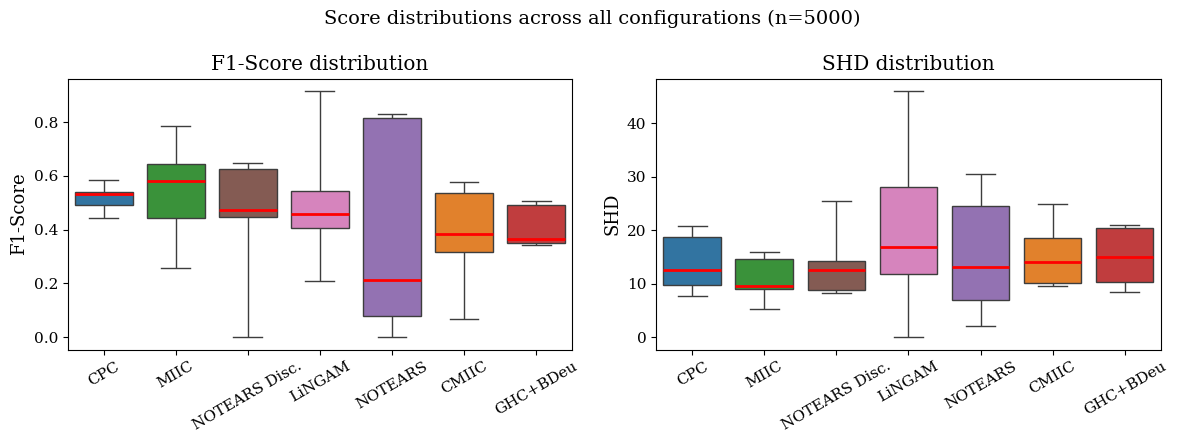

In [9]:
# Collect mean F1 and SHD per algo per config
score_records = []
for ds_name, df in dfs.items():
    subset = df[df["n_samples"] == 5000]
    for n_vars in sorted(subset["n_vars"].unique()):
        sub = subset[subset["n_vars"] == n_vars]
        means = sub.groupby("algo")[["SHD", "F1-Score"]].mean()
        for algo in means.index:
            score_records.append({
                "dataset": ds_name,
                "n_vars": n_vars,
                "algo": algo,
                "F1-Score": means.loc[algo, "F1-Score"],
                "SHD": means.loc[algo, "SHD"],
            })
score_df = pd.DataFrame(score_records)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(
    data=score_df, x="algo", y="F1-Score", hue="algo",
    order=algo_order_by_avg, hue_order=algo_order_by_avg,
    palette=ALGO_COLORS, ax=ax1, legend=False,
    whis=[0, 100], fliersize=0,
    medianprops={"color": "red", "linewidth": 2},
)
ax1.set_title("F1-Score distribution")
ax1.set_xlabel("")
ax1.set_ylabel("F1-Score")
ax1.tick_params(axis="x", rotation=30)

sns.boxplot(
    data=score_df, x="algo", y="SHD", hue="algo",
    order=algo_order_by_avg, hue_order=algo_order_by_avg,
    palette=ALGO_COLORS, ax=ax2, legend=False,
    whis=[0, 100], fliersize=0,
    medianprops={"color": "red", "linewidth": 2},
)
ax2.set_title("SHD distribution")
ax2.set_xlabel("")
ax2.set_ylabel("SHD")
ax2.tick_params(axis="x", rotation=30)

fig.suptitle("Score distributions across all configurations (n=5000)", fontsize=14)
fig.tight_layout()
plt.show()